In [1]:
#Data from https://pubmed.ncbi.nlm.nih.gov/24928188/

import pandas as pd
import numpy as np
import sklearn

In [2]:
df=pd.read_pickle("database.pickle")

In [3]:
df=pd.DataFrame(df).T

In [4]:
df.head()

,smiles,calc,d_calc,notes,iupac,PubChemID,d_expt,expt,groups,expt_reference,calc_reference
mobley_1323538,CCOP(=O)(OCC)OCC,-10.8,0.1,[Experimental uncertainty as suggested by 10.1...,triethylphosphate,6535,0.2,-7.5,[],10.1039/P29900000291,10.1021/jp0667442
mobley_2661134,c1cc(cc(c1)O)C#N,-6.99,0.03,[Experimental uncertainty not presently availa...,3-hydroxybenzonitrile,13394,0.6,-9.65,"[phenol or hydroxyhetarene, carbonitrile, arom...",10.1021/jp0764384,10.1021/ct800409d
mobley_6929123,COC(=O)CCl,-3.92,0.02,[Experimental uncertainty not presently availa...,methyl 2-chloroacetate,7295,0.6,-4.0,"[alkyl chloride, carboxylic acid ester]",10.1139/v80-201,10.1021/ct800409d
mobley_3395921,C1CCOCC1,-1.78,0.02,[Experimental uncertainty not presently availa...,tetrahydropyran,8894,0.6,-3.12,"[dialkyl ether, heterocyclic]",10.1021/jp0764384,10.1021/ct800409d
mobley_5449201,CCCCC,2.6,0.1,[Experimental uncertainty as suggested by 10.1...,n-pentane,8003,0.2,2.3,[],10.1039/P29900000291,10.1021/jp0667442


In [5]:
mols=df["smiles"]
vals=df["expt"]

In [6]:
data = {"Mols":mols, "Vals": vals}
df2=pd.DataFrame(data)
df2=df2.dropna()

In [8]:
import rdkit
from rdkit import Chem

mols=df2["Mols"]
values=df2["Vals"]


import numpy as np

mols=np.array([Chem.MolFromSmiles(i) for i in mols])


In [9]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
from rdkit.Chem import DataStructs


for mol in mols:
    AllChem.Compute2DCoords(mol)
X = []
for mol in mols:
    arr = np.zeros((0,))
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2)
    DataStructs.ConvertToNumpyArray(fp, arr)
    X.append(arr)       

In [10]:
X=np.array(X)
y=np.array(vals)

In [11]:
from sklearn.ensemble import RandomForestRegressor

reg=RandomForestRegressor()
reg.fit(X,y)
pred_y=reg.predict(X)

In [12]:
import joblib

filename = 'HE.sav'
joblib.dump(reg, filename)

['HE.sav']

In [79]:
import seaborn as sns
from scipy import stats
def r2(x, y):
    return stats.pearsonr(x, y)[0] ** 2

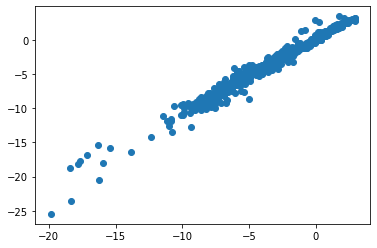

In [83]:
pred_y=reg.predict(X)

import matplotlib.pyplot as plt

plt.scatter(pred_y, y)

In [84]:
from sklearn.metrics import mean_squared_error
from math import sqrt

#calculate RMSE
sqrt(mean_squared_error(pred_y, y))

0.7271401951520448